(569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0 

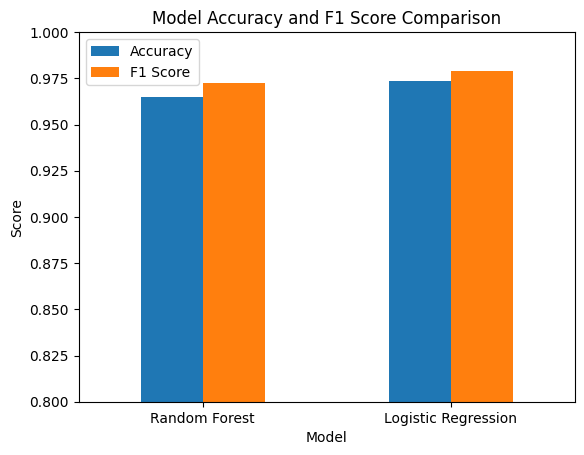

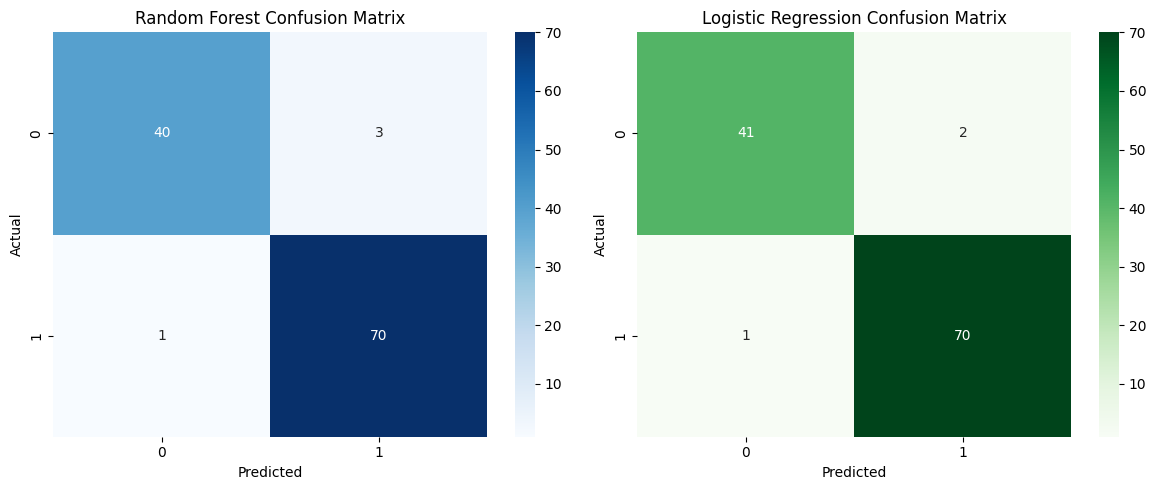

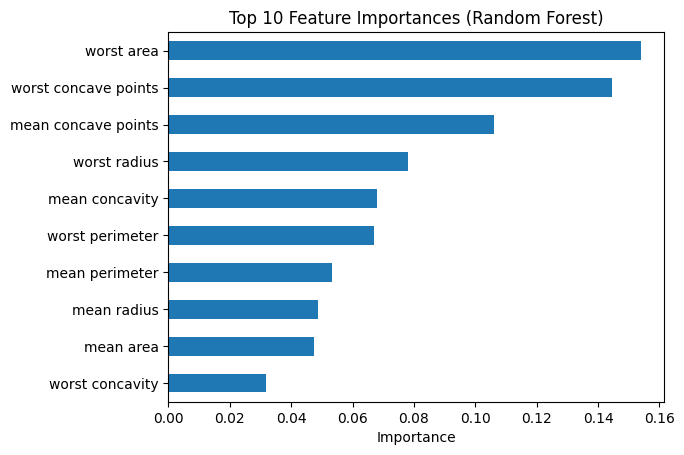

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler



X, y = load_breast_cancer(return_X_y=True, as_frame=True)


print(X.shape)
print(X.head())
print(X.describe())


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


pipeline_rf = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(random_state=42)
)


pipeline_logreg = make_pipeline(
    SimpleImputer(),
    StandardScaler(),         # <--- scale the data!
    LogisticRegression(max_iter=2000, random_state=42)
)


pipeline_rf.fit(X_train, y_train)
pipeline_logreg.fit(X_train, y_train)


rf_pred = pipeline_rf.predict(X_test)
logreg_pred = pipeline_logreg.predict(X_test)


results = {
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, logreg_pred)
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, logreg_pred)
    ]
}
results_df = pd.DataFrame(results)
print(results_df)


results_df.plot(x="Model", y=["Accuracy", "F1 Score"], kind="bar")
plt.title("Model Accuracy and F1 Score Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, logreg_pred), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Logistic Regression Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


rf_model = pipeline_rf.named_steps['randomforestclassifier']
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


load_wine = load_wine(as_frame=True)

X = load_wine.data
y = load_wine.target

print(X.head())
print(X.shape)
print(X.class_distribution)
print(X.describe())



